In [104]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import copy
from torchvision.datasets import ImageFolder
import random
import numpy as np
from torchvision import transforms
import time
import torch.nn as nn
import torchvision.models as models
from PIL import Image

from torchvision.datasets import Flowers102
from torchvision import transforms


In [106]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [107]:
# Fixed global seed for full experiment reproducibility
SEED = 42

# Controls randomness from the `random` module
random.seed(SEED)

# Controls randomness in NumPy operations
np.random.seed(SEED)

# Ensures deterministic behavior for PyTorch CPU operations
torch.manual_seed(SEED)

# DataLoader worker seeding
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [108]:
# Includes data augmentation to improve generalization
train_transform = transforms.Compose([
    
    # Resize the shorter side to 256 pixels
    transforms.Resize(256), #  Shape: (H, W, 3) → (H', W', 3), where min(H', W') = 256

    # Randomly crop and resize to 224×224
    transforms.RandomCrop(224),  # Shape: (H', W', 3) → (224, 224, 3)

    # Random horizontal flip (with probability p=0.5)
    transforms.RandomHorizontalFlip(p = 0.5),
    
    # Random color perturbations (brightness, contrast, saturation, hue)
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),

    # Convert PIL Image to PyTorch Tensor
    # (H, W, C) → (C, H, W), values scaled to [0.0, 1.0]
    transforms.ToTensor(),  # Shape: (224, 224, 3) → (3, 224, 224)

     # Normalize using ImageNet statistics (per channel)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# No random augmentations to ensure deterministic evaluation
val_test_transform = transforms.Compose([

    # Resize the shorter side to 256 pixels
    transforms.Resize(256),   # Shape: (H, W, 3) → (H', W', 3), min(H', W') = 256
    transforms.CenterCrop(224),  # Shape: (H', W', 3) → (224, 224, 3)
    
    transforms.ToTensor(),  # Shape: (224, 224, 3) → (3, 224, 224)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [ ]:

batch_size = 64
SEED = 42   

train_data = datasets.Flowers102(
    root="data",         
    split="train",
    transform=train_transform,
    download=True   
)

val_data = datasets.Flowers102(
    root="data",
    split="val",
    transform=val_test_transform,
    download=True
)

test_data = datasets.Flowers102(
    root="data",
    split="test",
    transform=val_test_transform,
    download=True
)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
   
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)


# DataLoaders 
train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    generator=g,
    worker_init_fn=seed_worker,

)

val_dataloader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    generator=g,
    worker_init_fn=seed_worker,
  
)

test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    generator=g,
    worker_init_fn=seed_worker,
 
)

In [110]:
class ConvParallelAdapter(nn.Module):
    
    def __init__(self, channels, rank=32):
        super().__init__()
        
        self.adapter = nn.Sequential(
          
            nn.Conv2d(channels, rank, kernel_size=1, bias=False),
            nn.ReLU(inplace=True), 
      
            nn.Conv2d(rank, rank, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True), 

            nn.Conv2d(rank, channels, kernel_size=1, bias=True)
        )
      
        self.alpha = nn.Parameter(torch.ones(1))
        nn.init.zeros_(self.adapter[-1].weight)
        nn.init.zeros_(self.adapter[-1].bias)
        
    def forward(self, x):
        return self.alpha * self.adapter(x)

In [111]:
class ResNet50WithParallelAdapters(nn.Module):
    
    def __init__(self, num_classes=102):
        
        super().__init__()

        # Loads ImageNet-pretrained weights
        self.backbone = models.resnet50(weights="IMAGENET1K_V1")

     
        self.adapter1 = ConvParallelAdapter(256, rank=16)
        self.adapter2 = ConvParallelAdapter(512, rank=32)
        self.adapter3 = ConvParallelAdapter(1024, rank=32)
        self.adapter4 = ConvParallelAdapter(2048, rank=64)  

        # Adapts model to Oxford-102 Flowers dataset
        self.backbone.fc = nn.Linear(
            self.backbone.fc.in_features, 
            num_classes
        )
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        
        x = self.backbone.conv1(x) 
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)  
        
        # ResNet Stage 1 + parallel adapter
        out = self.backbone.layer1(x)
        x = out + self.adapter1(out) # Parallel residual adaptation
        
        # ResNet Stage 2 + parallel adapter 
        out = self.backbone.layer2(x)
        x = out + self.adapter2(out)

        #  ResNet Stage 3 + parallel adapter
        out = self.backbone.layer3(x)
        x = out + self.adapter3(out)
 
        # ResNet Stage 4 + parallel adapter 
        out = self.backbone.layer4(x)
        x = out + self.adapter4(out)
        
        # Global Average Pooling + Classifier 
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x) # Final logits
       
        return x

In [112]:
model = ResNet50WithParallelAdapters(num_classes=102).to(device)
for param in model.backbone.parameters():
    param.requires_grad = False

# Enable adapters + classifier
for module in [model.adapter1, model.adapter2, model.adapter3, model.adapter4, model.backbone.fc]:
    for p in module.parameters():
        p.requires_grad = True

In [113]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
percentage = round(trainable/ total*100, 2)
print(f"Trainable params: {trainable:,}")
print(f"Total params:     {total:,}")
print("Trainable parameters: ", percentage, "%")

Trainable params: 639,082
Total params:     24,147,114
Trainable parameters:  2.65 %


In [114]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

In [115]:
def freeze_backbone_bn(model):
    for m in model.backbone.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()  # freeze running stats
            for p in m.parameters():
                p.requires_grad = False


In [116]:
def trainer(train_dataloader,  val_dataloader, model, loss_fn, optimizer, epochs, early_stop_patience, device, 
            scheduler=None, scheduler_type=None, max_norm=1.0
):
    no_improve_epochs = 0

    train_loss = []
    val_loss = []
    train_accuracy = []
    val_accuracy = []

    best_state = copy.deepcopy(model.state_dict())
    best_loss = float("inf")

    model = model.to(device)
    freeze_backbone_bn(model)

    for epoch in range(epochs):

        train_batch_loss = 0.0
        val_batch_loss = 0.0

        train_total = 0
        val_total = 0

        train_correct = 0
        val_correct = 0

        model.train()
        

        for X_train, y_train in train_dataloader:
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            optimizer.zero_grad(set_to_none=True)

            pred = model(X_train)
            loss = loss_fn(pred, y_train)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                (p for p in model.parameters() if p.requires_grad),
                max_norm=max_norm
            )

            optimizer.step()

            pred_labels = pred.argmax(dim=1)

            train_batch_loss += loss.item() * y_train.size(0)
            train_total += y_train.size(0)
            train_correct += (pred_labels == y_train).sum().item()

        train_loss.append(train_batch_loss / max(train_total, 1))
        train_accuracy.append(train_correct / max(train_total, 1))

     
        model.eval()
        with torch.no_grad():
            for X_val, y_val in val_dataloader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                pred = model(X_val)
                loss = loss_fn(pred, y_val)

                val_batch_loss += loss.item() * y_val.size(0)

                pred_labels = pred.argmax(dim=1)
                val_correct += (pred_labels == y_val).sum().item()
                val_total += y_val.size(0)

        val_loss.append(val_batch_loss / max(val_total, 1))
        val_accuracy.append(val_correct / max(val_total, 1))

        print(
            f"Epoch [{epoch+1:03d}/{epochs}] | "
            f"Train Loss: {train_loss[-1]:.4f}, "
            f"Train Acc: {train_accuracy[-1]:.4f} | "
            f"Val Loss: {val_loss[-1]:.4f}, "
            f"Val Acc: {val_accuracy[-1]:.4f}"
        )

      
        if val_loss[-1] < best_loss:
            best_loss = val_loss[-1]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, "resnet50_low_rank_adapter.pth")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

     
        if scheduler is not None:
            if scheduler_type == "plateau":
                scheduler.step(val_loss[-1])
            elif scheduler_type == "epoch":
                scheduler.step()
            else:
                raise ValueError("scheduler_type must be 'plateau' or 'epoch'")

        if no_improve_epochs >= early_stop_patience:
            print(f"Stopped early at epoch: {epoch+1}")
            break

    model.load_state_dict(best_state)

    result = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
    }

    return result


In [117]:
epochs = 40
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

In [118]:
start_time = time.time()

results = trainer(
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=epochs,
    early_stop_patience=5,
    device=device,
    scheduler=scheduler,
    scheduler_type="epoch",
    max_norm=1.0
)
end_time = time.time()

total_seconds = end_time - start_time
total_minutes = total_seconds / 60

print(f"Total training time: {total_minutes:.2f} minutes")

Epoch [001/40] | Train Loss: 4.6649, Train Acc: 0.0216 | Val Loss: 4.3390, Val Acc: 0.1157
Epoch [002/40] | Train Loss: 4.1993, Train Acc: 0.1882 | Val Loss: 3.9440, Val Acc: 0.4275
Epoch [003/40] | Train Loss: 3.7137, Train Acc: 0.5108 | Val Loss: 3.5781, Val Acc: 0.4902
Epoch [004/40] | Train Loss: 3.1343, Train Acc: 0.6637 | Val Loss: 2.8786, Val Acc: 0.5902
Epoch [005/40] | Train Loss: 2.6515, Train Acc: 0.7637 | Val Loss: 2.5511, Val Acc: 0.6539
Epoch [006/40] | Train Loss: 2.2862, Train Acc: 0.8059 | Val Loss: 2.1669, Val Acc: 0.7588
Epoch [007/40] | Train Loss: 1.9975, Train Acc: 0.8618 | Val Loss: 2.0156, Val Acc: 0.7716
Epoch [008/40] | Train Loss: 1.7968, Train Acc: 0.8873 | Val Loss: 1.9130, Val Acc: 0.8373
Epoch [009/40] | Train Loss: 1.5871, Train Acc: 0.9167 | Val Loss: 1.7428, Val Acc: 0.8275
Epoch [010/40] | Train Loss: 1.4816, Train Acc: 0.9333 | Val Loss: 1.7157, Val Acc: 0.8216
Epoch [011/40] | Train Loss: 1.3612, Train Acc: 0.9569 | Val Loss: 1.6523, Val Acc: 0.8353

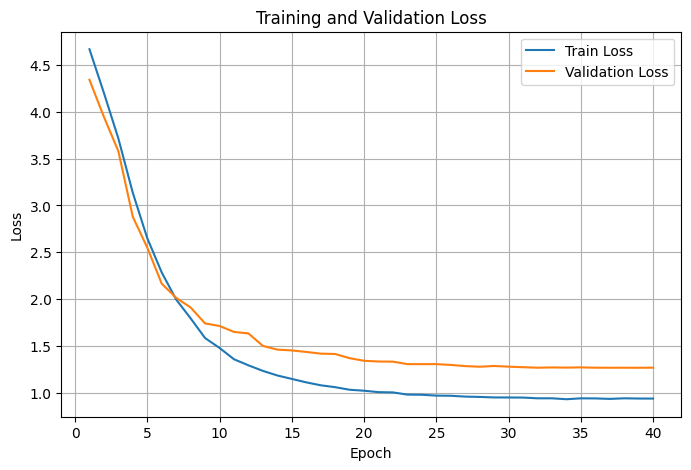

In [119]:
epochs = range(1, len(results["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, results["train_loss"], label="Train Loss")
plt.plot(epochs, results["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


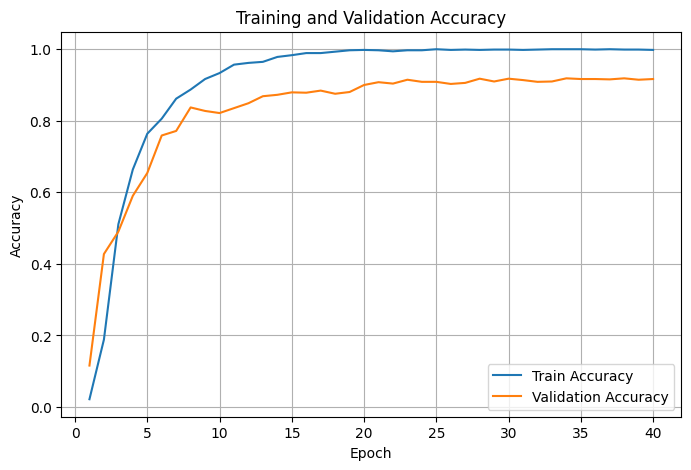

In [120]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, results["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, results["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [176]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_dataloader:

        images = images.to(device)
        labels = labels.to(device) 

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 89.20%


In [190]:
import json
with open("class_to_idx.json", "r") as f:
    class_to_idx = json.load(f)

# reverse mapping
idx_to_class = {i: str(i+1) for i in range(102)}

with open("cat_to_name.json", "r") as f:
    cat_to_name = json.load(f)


def predict_image(image_path, model, transform, device, idx_to_class, cat_to_name, top_k=5):
    
    model.eval()
    model.to(device)

    # Load image
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)

        top_probs, top_indices = torch.topk(probs, top_k)

    top_probs = top_probs.cpu().squeeze().numpy()
    top_indices = top_indices.cpu().squeeze().numpy()

    # Convert indices → class labels
    top_classes = [idx_to_class[int(idx)] for idx in top_indices]

    # Convert → flower names
    top_labels = [cat_to_name[str(cls)] for cls in top_classes]

    return top_probs, top_labels


probs, labels = predict_image(
    image_path="daisy.jpg",
    model=model,
    transform=val_test_transform,
    device=device,
    idx_to_class=idx_to_class,
    cat_to_name=cat_to_name,
    top_k=5
)

for p, l in zip(probs, labels):
    print(f"{l}: {p:.4f}")

oxeye daisy: 0.7295
barbeton daisy: 0.0452
sunflower: 0.0260
black-eyed susan: 0.0139
osteospermum: 0.0137
